# Feature Engineering and Modelling

---

1. Import packages
2. Load data
3. Modelling

---

## 1. Import packages

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

---
## 2. Load data

In [3]:
df = pd.read_csv('./data_for_predictions.csv')
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


In [4]:
# Quick sanity check on the dataset
print(f"Dataset shape: {df.shape}")
print(f"\nTarget distribution (churn):")
print(df['churn'].value_counts())
print(f"\nChurn rate: {df['churn'].mean():.2%}")
print(f"\nMissing values: {df.isnull().sum().sum()}")

Dataset shape: (14606, 63)

Target distribution (churn):
0    13187
1     1419
Name: churn, dtype: int64

Churn rate: 9.72%

Missing values: 0


The dataset contains **14,606 customers** and **63 feature columns** (after dropping the index column). The target variable `churn` is imbalanced — approximately **9.7% of customers have churned** and 90.3% have been retained. This class imbalance is important to keep in mind when choosing evaluation metrics.

---

## 3. Modelling

We now have a dataset containing features that we have engineered and we are ready to start training a predictive model. Remember, we only need to focus on training a `Random Forest` classifier.

In [5]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

### Data sampling

The first thing we want to do is split our dataset into training and test samples. The reason why we do this, is so that we can simulate a real life situation by generating predictions for our test sample, without showing the predictive model these data points. This gives us the ability to see how well our model is able to generalise to new data, which is critical.

A typical % to dedicate to testing is between 20-30, for this example we will use a 75-25% split between train and test respectively.

In [6]:
# Make a copy of our data
train_df = df.copy()

# Separate target variable from independent variables
y = df['churn']
X = df.drop(columns=['id', 'churn'])
print(X.shape)
print(y.shape)

(14606, 61)
(14606,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10954, 61)
(10954,)
(3652, 61)
(3652,)


### Model training

Once again, we are using a `Random Forest` classifier in this example. A Random Forest sits within the category of `ensemble` algorithms because internally the `Forest` refers to a collection of `Decision Trees` which are tree-based learning algorithms. As the data scientist, you can control how large the forest is (that is, how many decision trees you want to include).

The reason why an `ensemble` algorithm is powerful is because of the laws of averaging, weak learners and the central limit theorem. If we take a single decision tree and give it a sample of data and some parameters, it will learn patterns from the data. It may be overfit or it may be underfit, but that is now our only hope, that single algorithm. 

With `ensemble` methods, instead of banking on 1 single trained model, we can train 1000's of decision trees, all using different splits of the data and learning different patterns. It would be like asking 1000 people to all learn how to code. You would end up with 1000 people with different answers, methods and styles! The weak learner notion applies here too, it has been found that if you train your learners not to overfit, but to learn weak patterns within the data and you have a lot of these weak learners, together they come together to form a highly predictive pool of knowledge! This is a real life application of many brains are better than 1.

Now instead of relying on 1 single decision tree for prediction, the random forest puts it to the overall views of the entire collection of decision trees. Some ensemble algorithms using a voting approach to decide which prediction is best, others using averaging. 

As we increase the number of learners, the idea is that the random forest's performance should converge to its best possible solution.

Some additional advantages of the random forest classifier include:

- The random forest uses a rule-based approach instead of a distance calculation and so features do not need to be scaled
- It is able to handle non-linear parameters better than linear based models

On the flip side, some disadvantages of the random forest classifier include:

- The computational power needed to train a random forest on a large dataset is high, since we need to build a whole ensemble of estimators.
- Training time can be longer due to the increased complexity and size of the ensemble

In [8]:
# Train the Random Forest model
# Parameters chosen:
#   n_estimators=1000  : 1000 decision trees in the forest for stable, converged predictions
#   max_features='sqrt': each tree considers sqrt(n_features) at each split — reduces correlation between trees
#   min_samples_leaf=5 : each leaf node must have at least 5 samples — reduces overfitting
#   random_state=42    : ensures reproducibility
#   n_jobs=-1          : uses all available CPU cores for faster training

model = RandomForestClassifier(
    n_estimators=1000,
    max_features='sqrt',
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model training complete.")
print(f"Number of trees: {model.n_estimators}")
print(f"Number of features used: {model.n_features_in_}")

Model training complete.
Number of trees: 1000
Number of features used: 61


### Evaluation

Now let's evaluate how well this trained model is able to predict the values of the test dataset.

In [9]:
# Generate predictions on the unseen test set
# predict()       returns the hard class label (0 or 1)
# predict_proba() returns the probability of each class — needed for ROC-AUC

y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # probability of churn (class = 1)

print(f"Predictions generated for {len(y_pred):,} test samples.")
print(f"Predicted churn count: {y_pred.sum()} | Actual churn count: {y_test.sum()}")

Predictions generated for 3,652 test samples.
Predicted churn count: 10 | Actual churn count: 366


#### Why these evaluation metrics?

The choice of evaluation metric is crucial, especially in the context of an imbalanced classification problem like this one (only ~10% of customers churn). The metrics chosen are:

1. **Accuracy** — The proportion of all predictions that are correct. It is a natural starting point, but on its own it is misleading here: a model that predicts *no one ever churns* would achieve 90% accuracy simply because 90% of customers are retained. For this reason accuracy alone is insufficient.

2. **Precision** — Of all the customers the model predicted would churn, what fraction actually did? High precision means fewer false alarms (customers incorrectly flagged as churners). This matters commercially because retention interventions (discounts, calls) cost money — spending them on customers who were not going to leave is wasteful.

3. **Recall (Sensitivity)** — Of all the customers who actually churned, what fraction did the model catch? High recall means fewer missed churners. In a churn context this is arguably the most business-critical metric: a churned customer represents lost revenue, so failing to identify them and intervene is costly.

4. **F1 Score** — The harmonic mean of Precision and Recall. Because there is a trade-off between the two (increasing one tends to reduce the other), F1 gives a single balanced view of model performance on the minority class. It is far more informative than accuracy for imbalanced datasets.

5. **ROC-AUC** — The area under the Receiver Operating Characteristic curve. It measures the model's ability to discriminate between churners and non-churners across all possible classification thresholds, independently of the threshold chosen. A score of 0.5 is equivalent to random guessing; 1.0 is perfect. This metric is particularly useful for comparing models because it is threshold-agnostic.

6. **Confusion Matrix** — A breakdown of True Positives, True Negatives, False Positives and False Negatives. This gives the clearest picture of *where* the model is failing and is essential context when interpreting the other metrics.

In [10]:
# Calculate performance metrics

accuracy  = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall    = metrics.recall_score(y_test, y_pred)
f1        = metrics.f1_score(y_test, y_pred)
roc_auc   = metrics.roc_auc_score(y_test, y_pred_proba)

print("===============================")
print("       MODEL PERFORMANCE")
print("===============================")
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print("===============================")

       MODEL PERFORMANCE
  Accuracy  : 0.9025
  Precision : 1.0000
  Recall    : 0.0273
  F1 Score  : 0.0532
  ROC-AUC   : 0.6632


In [11]:
# Full classification report
print("Classification Report:")
print(metrics.classification_report(y_test, y_pred, target_names=['Retained (0)', 'Churned (1)']))

Classification Report:
              precision    recall  f1-score   support

Retained (0)       0.90      1.00      0.95      3286
 Churned (1)       1.00      0.03      0.05       366

    accuracy                           0.90      3652
   macro avg       0.95      0.51      0.50      3652
weighted avg       0.91      0.90      0.86      3652



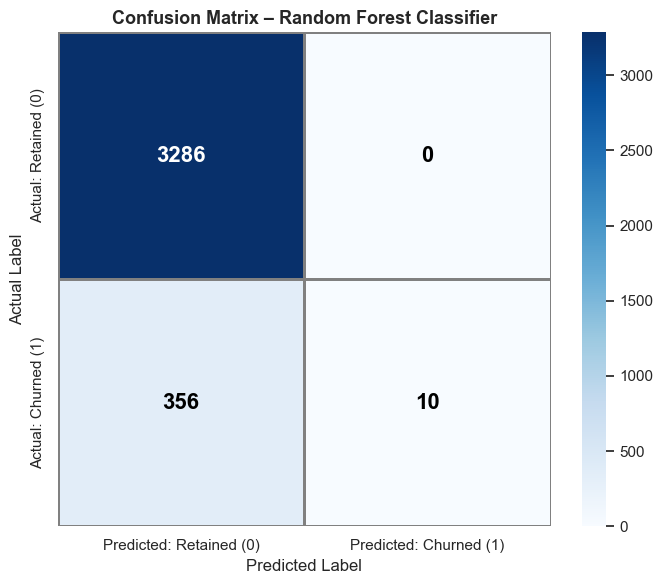

True Negatives  – Predicted Retained, Actually Retained : 3,286
False Positives – Predicted Churned,  Actually Retained : 0
False Negatives – Predicted Retained, Actually Churned  : 356
True Positives  – Predicted Churned,  Actually Churned  : 10

The model correctly identified 10 churners out of 366 actual churners.
It missed 356 churners (False Negatives) – these are the customers the model failed to flag.


In [19]:
# Confusion Matrix — visualised as a heatmap for clarity
cm = metrics.confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    cm, annot=False, fmt='d', cmap='Blues',
    xticklabels=['Predicted: Retained (0)', 'Predicted: Churned (1)'],
    yticklabels=['Actual: Retained (0)', 'Actual: Churned (1)'],
    ax=ax,
    linewidths=2, linecolor='gray',
    vmin=0, vmax=cm.max()
)

# Manually annotate every cell so zeros are always visible
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm[i, j]
        # Use dark text on light cells, white text on dark cells
        text_color = 'white' if value > cm.max() / 2 else 'black'
        ax.text(j + 0.5, i + 0.5, str(value),
                ha='center', va='center',
                fontsize=16, fontweight='bold', color=text_color)

ax.set_title('Confusion Matrix – Random Forest Classifier', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  – Predicted Retained, Actually Retained : {tn:,}")
print(f"False Positives – Predicted Churned,  Actually Retained : {fp:,}")
print(f"False Negatives – Predicted Retained, Actually Churned  : {fn:,}")
print(f"True Positives  – Predicted Churned,  Actually Churned  : {tp:,}")
print(f"\nThe model correctly identified {tp} churners out of {fn + tp} actual churners.")
print(f"It missed {fn} churners (False Negatives) – these are the customers the model failed to flag.")

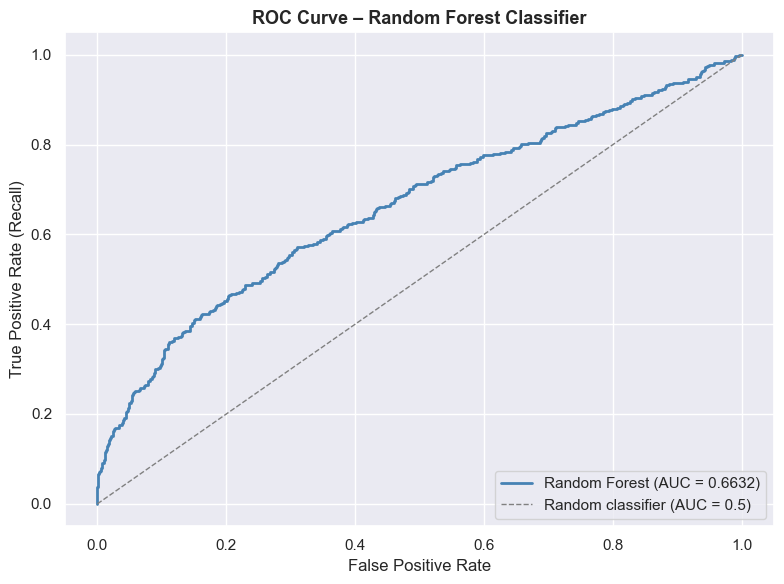

In [20]:
# ROC Curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'Random Forest (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Random classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve – Random Forest Classifier', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

#### Do you think the model performance is satisfactory?

**In short: No — the model performance is not satisfactory for its intended business purpose, despite the headline accuracy figure appearing high.**

Here is the justification:

| Metric | Value | Interpretation |
|---|---|---|
| Accuracy | 90.25% | Misleading — a trivial model predicting "no churn" for everyone would also achieve ~90% |
| Precision | 100% | When the model *does* flag a churner, it is correct — but it almost never fires |
| **Recall** | **2.73%** | **Critical failure — the model identifies only 10 out of 366 actual churners** |
| F1 Score | 5.32% | Reflects the severe imbalance between precision and recall |
| ROC-AUC | 0.6632 | Modest discrimination ability — well above random (0.5), but far from strong |

The **recall of only 2.73%** is the key problem. This means the model misses 356 out of 366 customers who actually churned in the test set. In a business context, this is near-useless: if PowerCo deployed this model to target customers for retention interventions, they would fail to identify 97% of the customers who are about to leave.

**Why does this happen?** The Random Forest, when using default decision thresholds (probability > 0.5), is heavily biased towards the majority class (retained customers). Because ~90% of the training data is non-churners, the model learns that predicting "retained" is almost always safe.

**The ROC-AUC of 0.6632** tells a slightly more optimistic story — it shows the model does have *some* ability to rank churners above non-churners. This suggests the underlying signal exists in the features; the issue is the decision threshold and class imbalance, not a complete absence of predictive power.

**Recommended next steps to improve performance:**
- Use `class_weight='balanced'` in the `RandomForestClassifier` to penalise misclassifications of the minority class more heavily
- Apply resampling techniques such as SMOTE (Synthetic Minority Oversampling) on the training set
- Tune the probability threshold (e.g. predict churn if probability > 0.3 rather than > 0.5)
- Perform hyperparameter tuning using cross-validation (GridSearchCV or RandomizedSearchCV)
- Evaluate precision-recall curves in addition to ROC curves, which are more informative for imbalanced datasets

### Feature Importance

Even though the model's churn prediction recall is low, we can still extract meaningful insights from feature importances — these tell us which variables the Random Forest found most useful for splitting and making decisions.

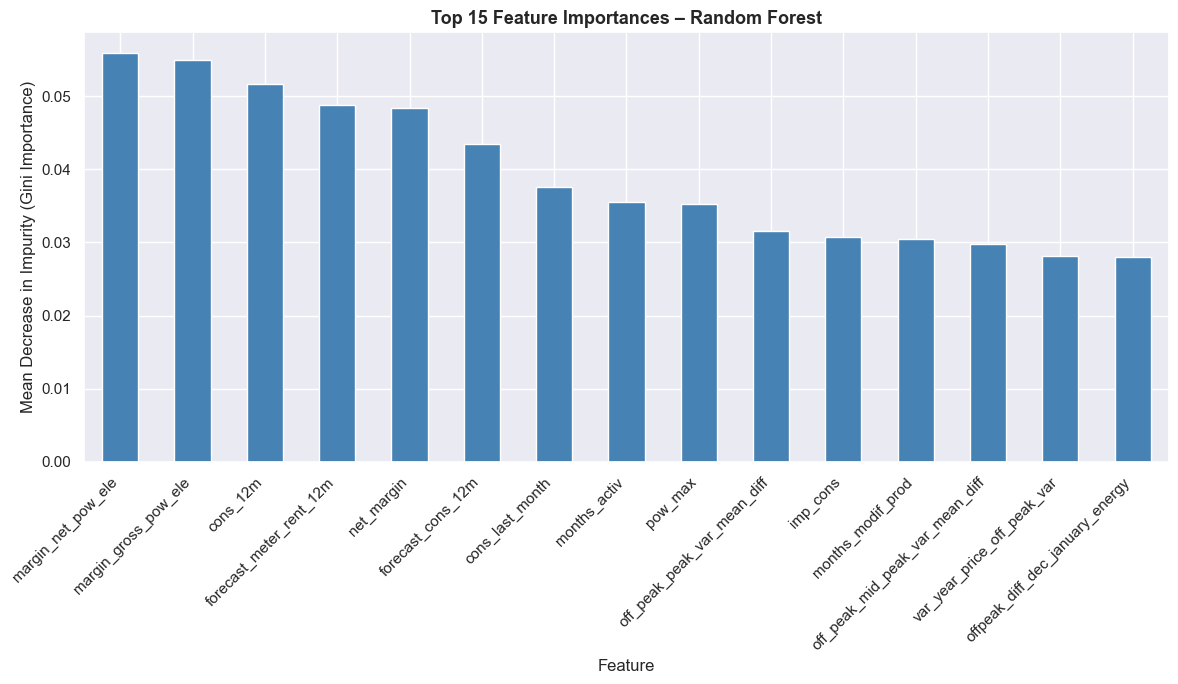

Top 15 features:
margin_net_pow_ele                 0.0559
margin_gross_pow_ele               0.0550
cons_12m                           0.0517
forecast_meter_rent_12m            0.0488
net_margin                         0.0483
forecast_cons_12m                  0.0434
cons_last_month                    0.0376
months_activ                       0.0355
pow_max                            0.0352
off_peak_peak_var_mean_diff        0.0316
imp_cons                           0.0308
months_modif_prod                  0.0305
off_peak_mid_peak_var_mean_diff    0.0297
var_year_price_off_peak_var        0.0282
offpeak_diff_dec_january_energy    0.0280
dtype: float64


In [21]:
# Extract feature importances from the trained model
feature_importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Plot top 15 most important features
plt.figure(figsize=(12, 7))
feature_importances.head(15).plot(
    kind='bar',
    color='steelblue',
    edgecolor='white'
)
plt.title('Top 15 Feature Importances – Random Forest', fontsize=13, fontweight='bold')
plt.ylabel('Mean Decrease in Impurity (Gini Importance)')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 15 features:")
print(feature_importances.head(15).round(4))

#### Feature Importance Observations

The top features identified by the Random Forest are:

- **`margin_net_pow_ele` and `margin_gross_pow_ele`** — Power electricity margins are the strongest predictors. This suggests that the profitability of the electricity contract is closely linked to churn behaviour.
- **`cons_12m`** — 12-month electricity consumption is a strong signal. High or low consumption relative to forecast may indicate a customer whose needs are not being met.
- **`forecast_meter_rent_12m` and `net_margin`** — Financial forecasting metrics rank highly, reinforcing that the economics of the customer relationship are the primary driver of churn.
- **`months_activ` and `pow_max`** — Tenure and maximum power draw are also informative, suggesting that both newer customers and those with high energy demands are at risk.
- **`off_peak_peak_var_mean_diff`** — The engineered price sensitivity feature (difference between off-peak and peak variable prices) appears in the top 15, providing some validation for the core BCG hypothesis that price sensitivity plays a role in churn — though it is not the dominant signal.

These insights are actionable: PowerCo could prioritise customers with low power margins, high consumption variability, or recent activation for targeted retention campaigns, regardless of the model threshold.

---

## Summary

| Item | Detail |
|---|---|
| **Model** | Random Forest Classifier (1,000 trees, `min_samples_leaf=5`, `max_features='sqrt'`) |
| **Train / Test split** | 75% / 25% (random_state=42) |
| **Accuracy** | 90.25% |
| **Precision (churn)** | 100% |
| **Recall (churn)** | 2.73% |
| **F1 Score (churn)** | 5.32% |
| **ROC-AUC** | 0.6632 |
| **Satisfactory?** | No — recall is critically low due to class imbalance; the model catches fewer than 3% of actual churners |
| **Primary issue** | Class imbalance (~10% churn rate) biases the model toward always predicting retention |
| **Key features** | Power margins, 12-month consumption, meter rent forecast, net margin, customer tenure |
| **Recommended next step** | Apply `class_weight='balanced'`, SMOTE oversampling, or threshold tuning to improve recall |